<a href="https://colab.research.google.com/github/Aleksandras17/Brain-tumor-segemtation-neural-network/blob/main/Pretrained_resnet34_encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/brain_tumor_data/dataset

!unzip -q -o "/content/drive/MyDrive/Brain tumor segmentation data/1512427 (Unzipped Files)/brainTumorDataPublic_1-766.zip" -d /content/brain_tumor_data/dataset
!unzip -q -o "/content/drive/MyDrive/Brain tumor segmentation data/1512427 (Unzipped Files)/brainTumorDataPublic_1533-2298.zip" -d /content/brain_tumor_data/dataset
!unzip -q -o "/content/drive/MyDrive/Brain tumor segmentation data/1512427 (Unzipped Files)/brainTumorDataPublic_2299-3064.zip" -d /content/brain_tumor_data/dataset
!unzip -q -o "/content/drive/MyDrive/Brain tumor segmentation data/1512427 (Unzipped Files)/brainTumorDataPublic_767-1532.zip" -d /content/brain_tumor_data/dataset

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from scipy.io import loadmat
import h5py
import cv2
import albumentations as A

class BrainTumorDataset(Dataset):
  def __init__(self, paths,  augment = False):
    self.file_paths = paths
    self.augment = augment

    self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.Affine(
              translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
              scale=(0.9, 1.1),
              rotate=(-15, 15),
              border_mode=cv2.BORDER_CONSTANT,
              p=0.5
            ),
            A.ElasticTransform(
                alpha=750,
                sigma=11,
                border_mode=cv2.BORDER_CONSTANT,
                p=0.4
            ),
            A.RandomBrightnessContrast(
                brightness_limit=(-0.3, 0.3),
                contrast_limit=0.2,
                p=0.4
            ),
            A.GaussNoise(
                std_range=(0.01, 0.05),
                p = 0.2
            )
        ]) if augment else None

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, idx):
    with h5py.File(self.file_paths[idx], 'r') as f:


      cjdata = f['cjdata']

      image = np.array(cjdata['image']).astype(np.float32).T
      binary_mask = np.array(cjdata['tumorMask']).astype(np.float32).T
      label_id = int(cjdata['label'][0, 0])
    if image.shape != (512, 512):
      image = cv2.resize(image, (512, 512))

    if binary_mask.shape != (512, 512):
      binary_mask = cv2.resize(binary_mask, (512, 512), interpolation = cv2.INTER_NEAREST)

    #normalizing
    image = (image - np.min(image))/(np.max(image)-np.min(image) + 1e-7)

    if self.augment:
            augmented = self.transform(
                image=image[:, :, np.newaxis],
                mask=binary_mask
            )
            image = augmented['image'][:, :, 0]
            binary_mask = augmented['mask']

    mask = binary_mask*label_id

    image = torch.from_numpy(image).unsqueeze(0)
    mask = torch.from_numpy(mask).long()

    return image, mask

In [ ]:
import json
split_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/splits.json'

with open(split_path, 'r') as f:
  splits = json.load(f)

train = splits['train']
val = splits['val']
test = splits['test']




t_set = BrainTumorDataset(train, augment=True)
v_set = BrainTumorDataset(val)
test_set = BrainTumorDataset(test)




train_loader = torch.utils.data.DataLoader(t_set, batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(v_set, batch_size=8, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=8, shuffle=True)

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

from torchvision import models


class Net(nn.Module):
  def __init__(self, in_channels, out_channels):
    super(Net, self).__init__()


    backbone = models.resnet34(weights = 'DEFAULT')

    #pretrained encoder
    self.input_adapter = nn.Conv2d(1, 3, kernel_size=1)
    self.conv1 = backbone.conv1
    self.down1 = backbone.layer1
    self.down2 = backbone.layer2
    self.down3 = backbone.layer3
    self.down4 = backbone.layer4
    self.bn1 = backbone.bn1
    self.relu = backbone.relu
    self.maxpool = backbone.maxpool



    self.bottleneck = nn.Sequential(
        nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(1024),
        nn.ReLU(inplace=True),
        nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(1024)
    )

    #bottleneck residual
    self.r_bottleneck = nn.Sequential(
        nn.Conv2d(512, 1024, kernel_size=1),
        nn.BatchNorm2d(1024)
    )






    #decode

    self.up11 = nn.Sequential(
        nn.Conv2d(1024, 512, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True)
    )
    self.up12 = nn.Sequential(
        nn.Conv2d(512, 512, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(512)
    )

    self.up21 = nn.Sequential(
        nn.Conv2d(512, 256, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True)
        )
    self.up22 = nn.Sequential(
        nn.Conv2d(256, 256, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(256)
    )

    self.up31 = nn.Sequential(
        nn.Conv2d(256, 128, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True)
    )
    self.up32= nn.Sequential(
        nn.Conv2d(128, 128, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(128)
        )

    self.up41 = nn.Sequential(
        nn.Conv2d(128, 64, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True)
        )
    self.up42 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=3, padding=1, bias = False),
        nn.BatchNorm2d(64),
        nn.Upsample(scale_factor=2)
    )

    #Output
    self.out = nn.Conv2d(64, out_channels, kernel_size =1)


    #Downsampling
    self.pool = nn.MaxPool2d(2,2)

    #Upsampling
    self.up_conv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)

    self.up_conv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)

    self.up_conv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)

    self.up_conv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)



    #Attention gates
    #gate4
    self.ag_skip4 = nn.Sequential(
        nn.Conv2d(512, 512, kernel_size=1, stride=1),
        nn.BatchNorm2d(512)
    )
    self.ag_sig4 = nn.Sequential(
        nn.Conv2d(1024, 512, kernel_size=1),
        nn.BatchNorm2d(512)
    )

    self.ag4 = nn.Sequential(
        nn.ReLU(inplace=True),
        nn.Conv2d(512, 1, kernel_size=1),
        nn.Sigmoid()
    )

    #gate3
    self.ag_skip3 = nn.Sequential(
        nn.Conv2d(256, 256, kernel_size=1, stride=1),
        nn.BatchNorm2d(256)
    )
    self.ag_sig3 = nn.Sequential(
        nn.Conv2d(512, 256, kernel_size=1),
        nn.BatchNorm2d(256)
    )

    self.ag3 = nn.Sequential(
        nn.ReLU(inplace=True),
        nn.Conv2d(256, 1, kernel_size=1),
        nn.Sigmoid()
    )

    #gate2
    self.ag_skip2 = nn.Sequential(
        nn.Conv2d(128, 128, kernel_size=1, stride=1),
        nn.BatchNorm2d(128)
    )
    self.ag_sig2 = nn.Sequential(
        nn.Conv2d(256, 128, kernel_size=1),
        nn.BatchNorm2d(128)
    )

    self.ag2 = nn.Sequential(
        nn.ReLU(inplace=True),
        nn.Conv2d(128, 1, kernel_size=1),
        nn.Sigmoid(),
    )

    #gate1
    self.ag_skip1 = nn.Sequential(
        nn.Conv2d(64, 64, kernel_size=1, stride=2),
        nn.BatchNorm2d(64)
    )
    self.ag_sig1 = nn.Sequential(
        nn.Conv2d(128, 64, kernel_size=1),
        nn.BatchNorm2d(64)
    )

    self.ag1 = nn.Sequential(
        nn.ReLU(inplace=True),
        nn.Conv2d(64, 1, kernel_size=1),
        nn.Sigmoid()
    )

    self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    #Dropout to prevent overfitting
    self.bottleneck_dropout = nn.Dropout2d(p=0.2)
    self.dropout = nn.Dropout2d(0.1)

  def forward(self, x):
    #s_i skip connections
    #r_i residual connections
      x = self.input_adapter(x)
      x = self.conv1(x)
      x = self.bn1(x)
      x = self.relu(x)

      s1 = self.down1(x)
      x = self.dropout(s1)
      x=self.pool(x)


      x = self.down2(x)
      s2 = self.dropout(x)

      x = self.down3(s2)
      s3 = self.dropout(x)


      x = self.down4(s3)
      s4 = self.dropout(x)

      r_bottleneck = self.r_bottleneck(s4)
      x = F.relu(self.bottleneck(s4)+r_bottleneck) #1024 channels
      x = self.bottleneck_dropout(x)

      #attention gate 4
      g_signal = self.ag_sig4(x)
      g_skip = self.ag_skip4(s4)
      ag = g_signal + g_skip
      ag = self.ag4(ag)

      #Upsampling
      x = self.up_conv1(x) #1024 to 512 channels

      #Decoding block 1

      x = torch.cat((self.upsample(ag*s4), x), dim=1)  #512 + 512 channels
      skip = self.up11(x) #  1024 to 512
      x = F.relu(skip+self.up12(skip))

      #Attention gate 3
      g_signal = self.ag_sig3(x)
      g_skip = self.ag_skip3(s3)
      ag = g_signal + g_skip
      ag = self.ag3(ag)

      #Upsampling
      x = self.up_conv2(x) #512 to 256

      #Decding block 2
      x = torch.cat((self.upsample(ag*s3), x), dim=1) #256 to 512
      skip = self.up21(x) # 512 to 256
      x = F.relu(skip+self.up22(skip))

      #Attention gate 2
      g_signal = self.ag_sig2(x)
      g_skip = self.ag_skip2(s2)
      ag = g_signal + g_skip
      ag = self.ag2(ag)

      #Upsampling
      x = self.up_conv3(x) # 256 to 128

      #decoding block 3
      x = torch.cat((self.upsample(ag*s2), x), dim=1) #128 + 128
      skip = self.up31(x)  #256 to 128
      x = F.relu(skip+self.up32(skip))


      #Attention gate 1
      g_signal = self.ag_sig1(x)
      g_skip = self.ag_skip1(s1)
      ag = g_signal + g_skip
      ag = self.ag1(ag)

      #Upsampling
      x = self.up_conv4(x) #128 to 64
      ag = self.upsample(ag)

      x = torch.cat((ag*s1, x), dim=1) #64+64
      skip = self.up41(x) #128 to 64
      x = F.relu(self.upsample(skip)+self.up42(skip))

      x = self.out(x) #64 to 2
      return x


In [ ]:
!pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.1 MB/s eta 0:00:00


In [ ]:
import torch
import segmentation_models_pytorch as smp


class combined_loss(nn.Module):
  def __init__(self, lamda = 0.6, gamma =2, alpha = 0.5, beta = 0.5):
    super().__init__()
    self.lamda = lamda
    self.focal = smp.losses.FocalLoss(mode = 'multiclass', gamma=gamma)
    self.tversky = smp.losses.TverskyLoss(mode = 'multiclass', alpha = alpha, beta = beta)

  def forward(self, logits, labels):
    focal_loss = self.focal(logits, labels)
    tversky_loss = self.tversky(logits, labels)
    return (self.lamda*focal_loss + (1-self.lamda)*tversky_loss), focal_loss, tversky_loss


In [ ]:
import torch
import numpy as np



def IoU(pred, ground, classes):
  eps = 1e-7
  total_intersection = np.zeros(3)
  total_union = np.zeros(3)
  for c in range(1, classes):
    p_c = (pred == c)
    g_c = (ground == c)
    total_intersection[c-1]+= torch.sum(p_c&g_c)
    total_union[c-1] += torch.sum(p_c|g_c)



  return total_intersection, total_union

In [ ]:
from tqdm import tqdm
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler

scaler = torch.amp.GradScaler('cuda')


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




def epoch(dataloader, loss_fn, model, optimizer, classes):
  model.train()
  total_loss = 0
  total_batches = 0
  total_FCE = 0
  total_FTL = 0
  total_intersection = 0
  total_union = 0


  with tqdm(dataloader, unit="batch", file=sys.stdout) as iterator:
    iterator.set_description("Train")

    for inputs, labels in iterator:
      inputs, labels = inputs.to(device), labels.to(device)
      optimizer.zero_grad()


      with autocast(device_type='cuda', dtype = torch.float16):
        logits = model(inputs)




        loss, FCE, FTL = loss_fn(logits, labels)


        total_FCE += FCE.item()
        total_FTL += FTL.item()
        total_loss += loss.item()



      scaler.scale(loss).backward()
      scaler.step(optimizer)
      scaler.update()

      predictions = torch.argmax(logits, dim=1)
      intersection, union = IoU(predictions, labels, 4)
      total_intersection += intersection
      total_union += union



      total_batches += 1
      iterator.set_postfix(average_batch_loss = (total_loss)/total_batches, intersection_over_union = total_intersection/(total_union+1e-7))

  return total_loss/len(dataloader), total_FCE/len(dataloader), total_FTL/len(dataloader)





def evaluation(dataloader, loss_fn, model, classes):
  model.eval()

  total_intersection = np.zeros(3)
  total_union = np.zeros(3)
  total_loss = 0
  total_batches = 0


  with torch.no_grad():
    with tqdm(dataloader, unit="batch", file=sys.stdout)as iterator:
      iterator.set_description("Validation")
      for inputs, labels in iterator:
          inputs, labels = inputs.to(device), labels.to(device)

          logits = model(inputs)


          predictions = torch.argmax(logits, dim=1)

          loss, FCE, FTL = loss_fn(logits, labels)

          intersection, union= IoU(predictions, labels, classes)


          iou = np.zeros(3)
          for c in range(classes-1):
            total_intersection[c] += intersection[c]
            total_union[c] += union[c]
            iou[c] = total_intersection[c]/(total_union[c]+1e-7)


          iterator.set_postfix(val_loss = loss, IoU_1 = iou[0], IoU_2 = iou[1], IoU_3 = iou[2])


    return loss, iou


In [ ]:
import json
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using {device}")

model = Net(1, 4).to(device)



history_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/history'
best_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/best_path.pth'
save_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/save_path.pth'
checkpoint_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/checkpoint.pth'





try:
  model.load_state_dict(torch.load(save_path, map_location=device))
  print("✅ Model weights loaded successfully! Ready to resume.")
except FileNotFoundError:
  print("No weight file")
except  Exception as e:
  print(f"❌ Error loading weights: {e}")

with open(history_path, 'r') as f:
  loaded_history = json.load(f)

FCE_history = loaded_history['CE_history']
FTL_history = loaded_history['DL_history']
IoU_history = loaded_history['IoU_history']

using cuda
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 276MB/s]


✅ Model weights loaded successfully! Ready to resume.


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn
import torch
import json
from torch.amp import autocast, GradScaler



history_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/history'
best_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/best_path.pth'
save_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/save_path.pth'
checkpoint_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/checkpoint.pth'



epochs = 10
lr = 0.001





device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")



loss_fn= combined_loss(lamda = 0.6, alpha = 0.65, beta = 0.35).to(device)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience= 10)

checkpoint = torch.load(checkpoint_path, weights_only = False)
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


for e in range(epochs):
  if len(IoU_history) > 0:
    best_IoU = max([np.mean(x) for x in IoU_history])
  else:
    best_IoU = 0
  loss, FCE, FTL = epoch(train_loader, loss_fn, model, optimizer,  4)
  FCE_history.append(FCE)
  FTL_history.append(FTL)
  val_loss, iou_score = evaluation(val_loader,loss_fn, model, 4)
  IoU_history.append(iou_score.tolist())
  scheduler.step(val_loss)


  print(f"epch {e} learning rate {optimizer.param_groups[0]['lr']}")
  if iou_score.mean() > best_IoU:
    torch.save(model.state_dict(), best_path)
    history = {
    'CE_history': FCE_history,
    'DL_history': FTL_history,
    'IoU_history': IoU_history
    }
    torch.save({
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'scheduler_state_dict': scheduler.state_dict()
    }, checkpoint_path)



    with open(history_path, 'w') as f:
      json.dump(history, f)
    print(f"Weights saved at epoch {e} new best IoU: {iou_score.mean()}")


print ("Training complete.")



history = {
    'CE_history': FCE_history,
    'DL_history': FTL_history,
    'IoU_history': IoU_history
}


with open(history_path, 'w') as f:
  json.dump(history, f)

torch.save(model.state_dict(), save_path)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}, checkpoint_path)

Using cuda device
Validation: 100%|██████████| 39/39 [00:01<00:00, 19.60batch/s, IoU_1=0.828, IoU_2=0.643, IoU_3=0.757, val_loss=tensor(0.0289, device='cuda:0')]
epch 0 learning rate 6.103515625e-08
Validation: 100%|██████████| 39/39 [00:02<00:00, 19.22batch/s, IoU_1=0.83, IoU_2=0.644, IoU_3=0.755, val_loss=tensor(0.0278, device='cuda:0')]
epch 1 learning rate 6.103515625e-08
Validation: 100%|██████████| 39/39 [00:01<00:00, 19.67batch/s, IoU_1=0.833, IoU_2=0.644, IoU_3=0.759, val_loss=tensor(0.0280, device='cuda:0')]
epch 2 learning rate 6.103515625e-08
Validation: 100%|██████████| 39/39 [00:02<00:00, 19.32batch/s, IoU_1=0.832, IoU_2=0.643, IoU_3=0.757, val_loss=tensor(0.0288, device='cuda:0')]
epch 3 learning rate 6.103515625e-08
Validation: 100%|██████████| 39/39 [00:01<00:00, 19.85batch/s, IoU_1=0.831, IoU_2=0.642, IoU_3=0.758, val_loss=tensor(0.0293, device='cuda:0')]
epch 4 learning rate 6.103515625e-08
Validation: 100%|██████████| 39/39 [00:01<00:00, 19.54batch/s, IoU_1=0.83, IoU

190
190


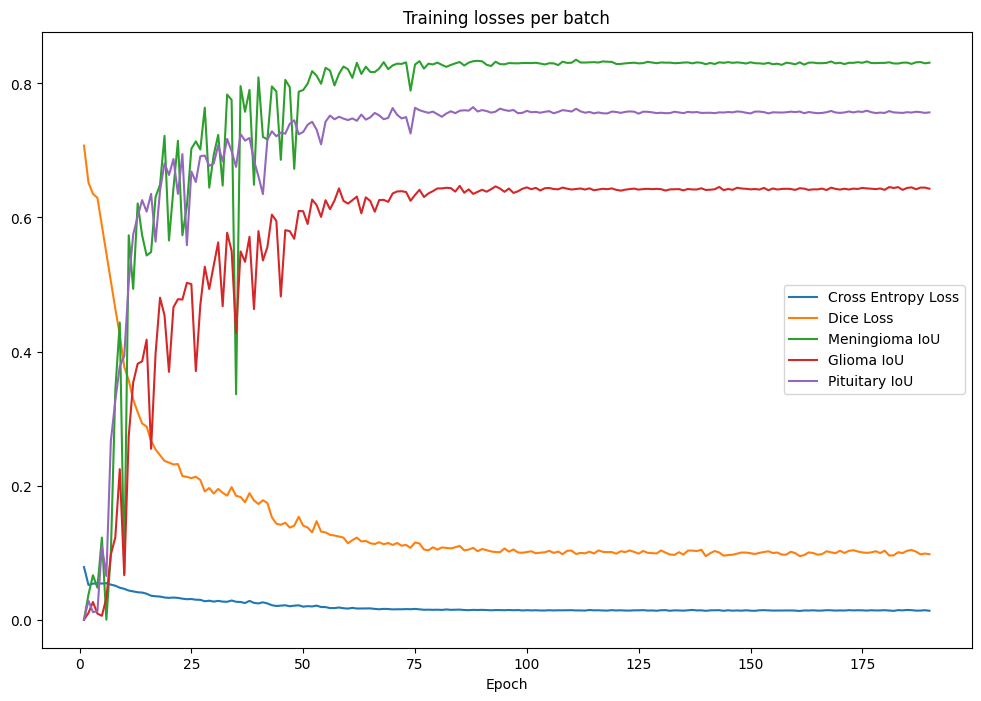

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import json

history_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/history'
best_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/best_path.pth'
save_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/save_path.pth'
checkpoint_path = '/content/drive/MyDrive/Brain tumor attention Res-Net/pre_trained/checkpoint.pth'


with open(history_path, 'r') as f:
  loaded_history = json.load(f)

CE_history = loaded_history['CE_history']
DL_history = loaded_history['DL_history']
IoU_history = loaded_history['IoU_history']

n = len(CE_history)
print(n)
epochs = np.arange(1, n+1)
print(len(epochs))
plt.figure(figsize=(12,8))
plt.plot(epochs, CE_history, label = "Cross Entropy Loss")
plt.plot(epochs, DL_history, label = "Dice Loss")
plt.plot(epochs, [iou[0] for iou in IoU_history], label = "Meningioma IoU")
plt.plot(epochs, [iou[1] for iou in IoU_history], label = "Glioma IoU")
plt.plot(epochs, [iou[2] for iou in IoU_history], label = "Pituitary IoU")



plt.title('Training losses per batch')
plt.xlabel('Epoch')
plt.legend()
plt.show()